# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [99]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
importlib.reload(up)


<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>





### Import human data

In [100]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_azim_spotlight_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("azimuth_spotlight_experiment/data/*.json"))

len(human_fnames)

205

## Process Human Results

In [142]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
results_df = results_df[results_df.itd_passed == True]
results_df = results_df[results_df.id_version == 1]


## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_azim_spotlight_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": (v['target_azim'], v['dist_azim_delta'], v['distractor_azim']) for k,v in stim_cond_map.items()}

# add as columns 
results_df['condition'], results_df['target_azim'], results_df['dist_azim_delta'], results_df['distractor_azim'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_target_azim_and_dist_detla(x, stim_cond_map=stim_cond_map)))

# # remap azimuths to be in the range -180 to 180 for plotting 
remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 
remap_azim = np.vectorize(remap_azim)
results_df['target_azim'] = remap_azim(results_df['target_azim'])
results_df['distractor_azim'] = remap_azim(results_df['distractor_azim'])
results_df['dist_azim_delta'] = remap_azim(results_df['dist_azim_delta'])


# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()

# trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 96
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

Unterminated string starting at: line 1 column 59747 (char 59746)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment/data/subj_5e544727059e3744ccdd4c3b.json


In [143]:
# trial_results = trial_results[trial_results.target_azim != - 90]

In [144]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  49
N good participants  46



#### Add re-scored performance based on entries included in excerpt transcripts  

In [145]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_azim_spotlight_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [146]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_azim_spotlight_stim_manifest.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'word',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
distractor_words = analysis_df.distractor_word.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
                            if not (isinstance(distractor_transcript, float)) else np.nan
                            for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df = analysis_df[analysis_df.condition != 'catch_trial']


In [147]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [148]:
analysis_df.condition.unique()

array(['spatialized'], dtype=object)

In [149]:
analysis_df.columns

Index(['trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'itd_passed', 'rt', 'response', 'stimulus',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'condition', 'target_azim',
       'dist_azim_delta', 'distractor_azim', 'accuracy', 'stim_name', 'word',
       'target_transcripts', 'distractor_transcripts', 'distractor_word',
       'confusions', 'adjusted_accuracy', 'adjusted_confusions'],
      dtype='object')

In [150]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["target_azim", "distractor_azim", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


# add distractor azimuth to dataframe. 


In [151]:
summary_df = (part_summary_df.groupby(["target_azim", "distractor_azim"]).agg({"adjusted_accuracy_mean":['mean', 'sem'], "adjusted_confusions_mean":['mean', 'sem']}).reset_index())
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df.columns = [col[:-1] if col.endswith('_') else col for col in summary_df.columns.values]

summary_df.columns = ['target_azim', 'distractor_azim', 'accuracy', 'adj_acc_sem', 'confusions', 'adj_conf_sem']
summary_df

,target_azim,distractor_azim,accuracy,adj_acc_sem,confusions,adj_conf_sem
0,-90.0,-90.0,0.597826,0.038447,0.086957,0.019376
1,-90.0,-80.0,0.570652,0.042323,0.065217,0.018116
2,-90.0,-70.0,0.570652,0.036994,0.065217,0.016365
3,-90.0,-60.0,0.641304,0.041596,0.086957,0.020877
4,-90.0,-50.0,0.635870,0.041635,0.032609,0.012551
5,-90.0,-30.0,0.711957,0.038043,0.054348,0.015372
6,-90.0,0.0,0.684783,0.042160,0.065217,0.018116
7,0.0,-90.0,0.608696,0.053643,0.108696,0.034449
8,0.0,-60.0,0.750000,0.043266,0.032609,0.018404
9,0.0,-40.0,0.782609,0.045715,0.010870,0.010870


### Prelim azimuth plots 

In [152]:
part_summary_df[part_summary_df.target_azim == 90]

,target_azim,distractor_azim,id_subject,correct_mean,correct_count,confusions_mean,adjusted_accuracy_mean,adjusted_confusions_mean
920,90.0,0.0,5422ae1afdf99b328c91b203,0.75,4,0.00,0.75,0.00
921,90.0,0.0,55a75835fdf99b26395fae40,0.75,4,0.00,1.00,0.00
922,90.0,0.0,55e356dac70c7a00052a57ec,0.50,4,0.00,1.00,0.00
923,90.0,0.0,5920b1f62b529b00013f3214,1.00,4,0.00,1.00,0.00
924,90.0,0.0,5a468280f7b7bc00014e08e6,0.75,4,0.00,0.75,0.00
...,...,...,...,...,...,...,...,...
1237,90.0,90.0,66846b62104a624f7ca29ca6,0.50,4,0.00,0.50,0.00
1238,90.0,90.0,6687f3a4aca3e2d5a6ca8d8b,0.50,4,0.25,0.75,0.25
1239,90.0,90.0,6688d16e085c316a7ced59c1,0.75,4,0.00,0.75,0.00
1240,90.0,90.0,66898c447c15ef8634f1c132,0.75,4,0.00,0.75,0.00


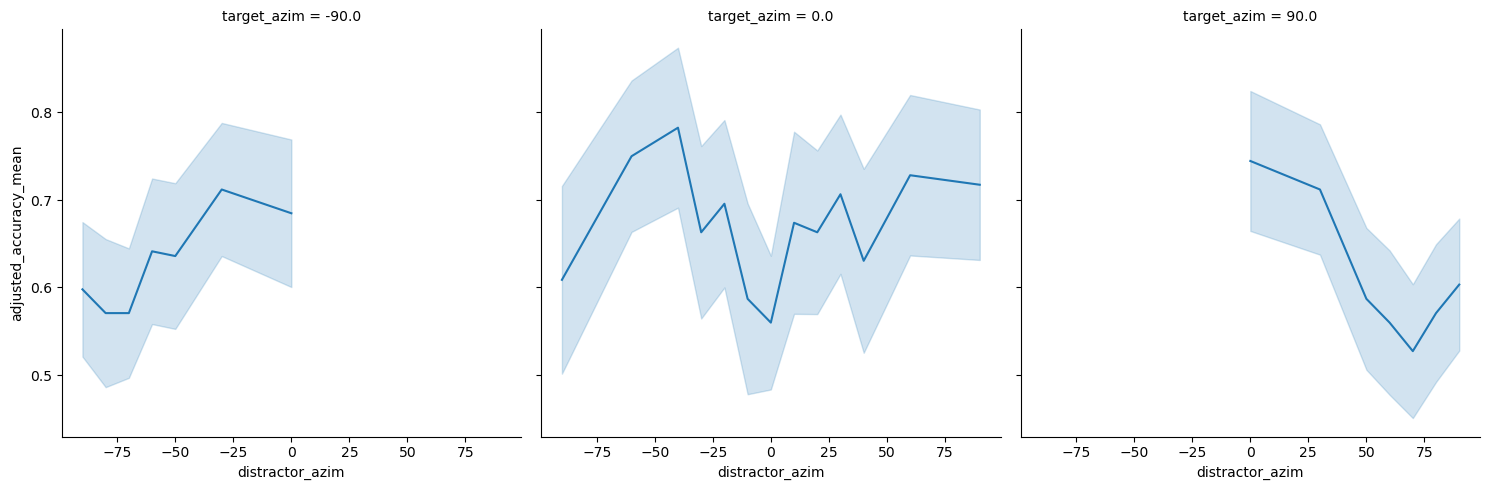

In [153]:
to_plot = part_summary_df.copy()
# to_plot['distractor_azim'] = to_plot['distractor_azim'].abs()
sns.relplot(data=to_plot,
            x='distractor_azim',
            y='adjusted_accuracy_mean',
            col='target_azim',
            errorbar=('se', 2),
            kind='line')

### Plot as function of distractor separation

In [154]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["target_azim", "dist_azim_delta", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


# add distractor azimuth to dataframe. 


Text(0.5, 1.0, 'Humans (N=46)')

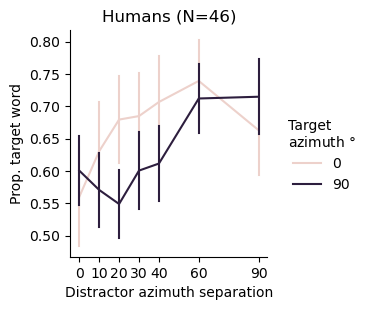

In [168]:
to_plot = part_summary_df.copy()
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='adjusted_accuracy_mean',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            height=3, aspect=1,
            kind='line')
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique())
# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
N = part_summary_df.id_subject.nunique()
plt.title(f"Humans (N={N})")

### Get model data and plot together

In [139]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/symmetric_distractor_test/word_task_half_co_loc_v07").glob("*0_SNR_min_reverb_room0000.pkl"))
stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v07']):# 'word_task_half_co_loc_v08']):
        continue
    # if 'v07' not in path.as_posix() and 'v08' not in path.as_posix():
    #     continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    dist_type = 'speech'
    if 'ssn' in path.stem:
        dist_type = 'noise'
    df['dist_type'] = dist_type
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)



    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('_')[1]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    
    results_dfs.append(df)

results = pd.concat(results_dfs)

results = results[(results.target_elev == 0) & (results.distractor_elev == 0)].reset_index()

In [169]:
df = pd.read_pickle("/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl")